
# Year 12 Software Engineering - Software Automation Module
### Assessment Task 1: Algorithmic Bias Audit

Name: Orlando

Class:

Date: 22/4/26



#### BACKGROUND

This dataset contains 450 simulated Centrelink welfare records.
The 'debt_raised_flag' column represents an automated algorithm
that compared ATO annual income data (divided by 26 to estimate
fortnightly earnings) against recipients' reported fortnightly
income. Where the ATO estimate exceeded the reported income,
the algorithm raised a debt against the recipient.

#### YOUR TASK

Use this script to investigate whether the algorithm produces
fair outcomes across all recipient groups, or whether certain
groups are disproportionately affected.

#### INSTRUCTIONS

Complete ALL sections marked with TODO comments.
Do NOT modify the section headers or variable names.
Run the script after completing each section to check your output.

## SECTION 0: Import Libraries

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

# scikit-learn is used in Section 4
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder

## SECTION 1: Load and Inspect the Dataset
##### Load the dataset

In [47]:
df = pd.read_csv('centrelink_income_dataset.csv')

##### 1.1 - Print the first 5 rows of the dataset

In [48]:
df.head()

,record_id,age_bracket,region,employment_type,payment_type,ato_annual_income,ato_calculated_fortnightly,reported_fortnightly_income,actual_fortnightly_income,income_variance_score,debt_raised_flag,estimated_debt_amount
0,CL1000,18-24,Regional QLD,Permanent Full-Time,Youth Allowance,36730,1412.69,1509.60,1505.50,6.6,0,0.00
1,CL1001,25-34,Regional VIC,Casual,JobSeeker,32524,1250.92,130.50,129.34,89.7,1,560.21
2,CL1002,18-24,Regional VIC,Casual,Youth Allowance,26050,1001.92,1150.45,1155.82,15.4,0,0.00
3,CL1003,35-44,Metro - Brisbane,Permanent Full-Time,Disability Support,69524,2674.00,2737.99,2805.88,4.9,0,0.00
4,CL1004,18-24,Remote,Casual,JobSeeker,20534,789.77,369.20,378.77,52.0,1,210.28


##### 1.2 - Print the shape of the dataset (number of rows and columns)

In [49]:
print(f"The number of rows is {df.shape[0]}, and the number of columns is {df.shape[1]}")

The number of rows is 450, and the number of columns is 12


##### 1.3 - Print summary statistics for numerical columns

In [50]:
df.describe()

,ato_annual_income,ato_calculated_fortnightly,reported_fortnightly_income,actual_fortnightly_income,income_variance_score,debt_raised_flag,estimated_debt_amount
count,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000
mean,41009.626667,1577.293444,1726.236400,1725.589956,46.554889,0.235556,88.488200
std,19166.080243,737.157156,1043.520487,1043.807828,52.363823,0.424818,183.753834
min,12827.000000,493.350000,2.540000,2.510000,0.100000,0.000000,0.000000
25%,25486.500000,980.247500,900.695000,904.792500,5.400000,0.000000,0.000000
50%,36998.500000,1423.020000,1674.440000,1661.325000,20.550000,0.000000,0.000000
75%,52428.500000,2016.482500,2521.935000,2541.927500,77.800000,0.000000,0.000000
max,92170.000000,3545.000000,5559.350000,5685.300000,212.000000,1.000000,940.900000


##### Count of each employment (provided)

In [51]:
df['employment_type'].value_counts()

employment_type
Permanent Full-Time    119
Casual                 113
Seasonal                98
Permanent Part-Time     70
Self-Employed           50
Name: count, dtype: int64

## SECTION 2: Calculating Debt Flag Rates by Group
A "debt flag rate" is the proportion of records in a group
where debt_raised_flag == 1. It tells us how often the
algorithm raised a debt for each category.

### 2A: By Employment Type

##### This calculation is provided as a worked example.

In [52]:
emp_group = df.groupby('employment_type')['debt_raised_flag'].agg(['sum', 'count'])
emp_group.columns = ['debts_raised', 'total_records']
emp_group['debt_flag_rate_%'] = (emp_group['debts_raised'] / emp_group['total_records'] * 100).round(1)
emp_group = emp_group.sort_values('debt_flag_rate_%', ascending=False)

print("\nDebt flag rate by employment type:")
print(emp_group)


Debt flag rate by employment type:
                     debts_raised  total_records  debt_flag_rate_%
employment_type                                                   
Seasonal                       42             98              42.9
Casual                         45            113              39.8
Self-Employed                  16             50              32.0
Permanent Part-Time             3             70               4.3
Permanent Full-Time             0            119               0.0


### 2B: By Region

##### 2.1 - Calculate debt flag rates grouped by 'region'

Follow the same pattern as the employment type example above.
Store your result in a variable called region_group

In [53]:
region_group = df.groupby('region')['debt_raised_flag'].agg(['sum', 'count'])
region_group.columns = ['debts_raised', 'total_records']
region_group['debt_flag_rate_%'] = (region_group['debts_raised'] / region_group['total_records'] * 100).round(1)
region_group = region_group.sort_values('debt_flag_rate_%', ascending=False)

##### 2.2 - Print the region_group table with a heading

In [54]:
print("\nDebt flag rate by region:")
print(region_group)


Debt flag rate by region:
                   debts_raised  total_records  debt_flag_rate_%
region                                                          
Regional QLD                 20             62              32.3
Remote                       19             61              31.1
Regional NSW                 17             68              25.0
Regional VIC                 17             72              23.6
Metro - Brisbane             13             58              22.4
Metro - Sydney               13             68              19.1
Metro - Melbourne             7             61              11.5


### 2C: By Age Bracket

##### 2.3 - Calculate debt flag rates grouped by age_bracket

Store your result in a variable called age_group

In [55]:
age_group = df.groupby('age_bracket')['debt_raised_flag'].agg(['sum', 'count'])
age_group.columns = ['debts_raised', 'total_records']
age_group['debt_flag_rate_%'] = (age_group['debts_raised'] / age_group['total_records'] * 100).round(1)
age_group = age_group.sort_values('debt_flag_rate_%', ascending=False)

##### 2.4 - Print the age_group table with a heading


In [56]:
print("\nDebt flag rate by age bracket:")
print(age_group)


Debt flag rate by age bracket:
             debts_raised  total_records  debt_flag_rate_%
age_bracket                                               
55-64                   9             32              28.1
18-24                  32            121              26.4
35-44                  26            109              23.9
25-34                  30            137              21.9
45-54                   9             51              17.6


## SECTION 3: Visualisations
You will create three bar charts. Each chart must have:
- A descriptive title
- Labelled axes (including units where appropriate)
- Readable bar labels showing the percentage value
- Appropriate colours

### Chart 1: Debt Flag Rate by Employment Type (Example Chart)

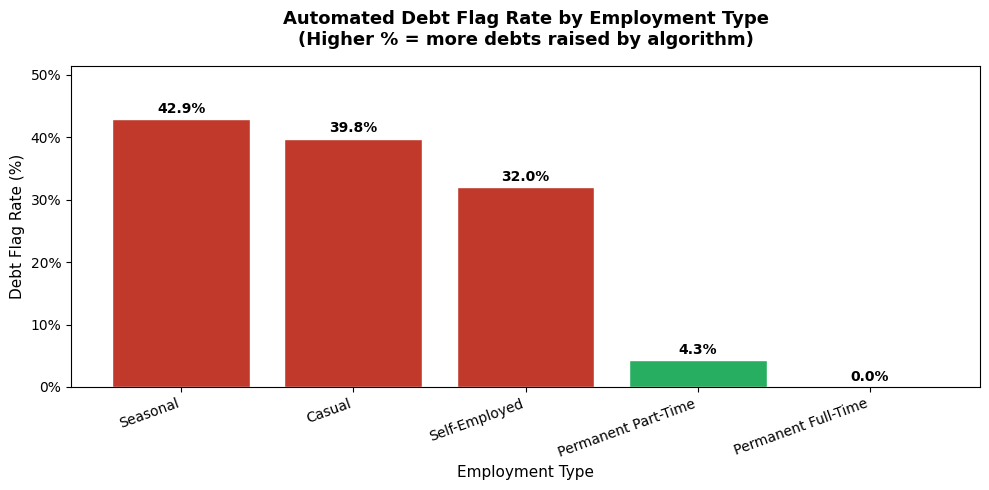

Chart 1 saved.


In [57]:
fig, ax = plt.subplots(figsize=(10, 5))

colours = ['#c0392b' if rate > 30 else '#e67e22' if rate > 15 else '#27ae60'
           for rate in emp_group['debt_flag_rate_%']]

bars = ax.bar(emp_group.index, emp_group['debt_flag_rate_%'], color=colours, edgecolor='white')

for bar, val in zip(bars, emp_group['debt_flag_rate_%']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{val}%', ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_title('Automated Debt Flag Rate by Employment Type\n(Higher % = more debts raised by algorithm)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Employment Type', fontsize=11)
ax.set_ylabel('Debt Flag Rate (%)', fontsize=11)
ax.set_ylim(0, max(emp_group['debt_flag_rate_%']) * 1.2)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('chart1_employment_bias.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved.")

### Chart 2: Debt Flag Rate by Region

##### 3.1 - Create a bar chart showing debt flag rate by region
- Use region_group['debt_flag_rate_%'] for the values
- Save the chart as 'chart2_regional_bias.png'
- Rotate x-axis labels by 30 degrees for readability

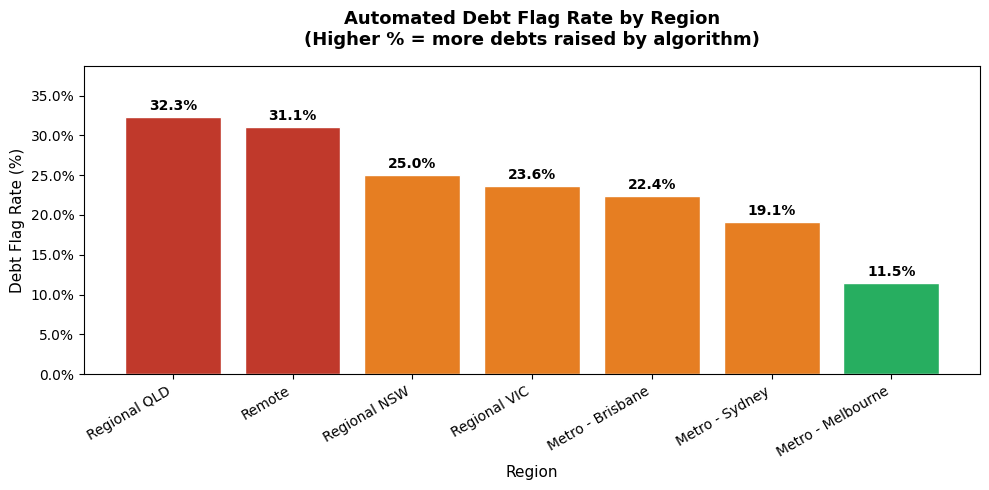

Chart 2 saved.


In [58]:
fig, ax = plt.subplots(figsize=(10, 5))

colours = ['#c0392b' if rate > 30 else '#e67e22' if rate > 15 else '#27ae60'
           for rate in region_group['debt_flag_rate_%']]

bars = ax.bar(region_group.index, region_group['debt_flag_rate_%'], color=colours, edgecolor='white')

for bar, val in zip(bars, region_group['debt_flag_rate_%']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{val}%', ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_title('Automated Debt Flag Rate by Region\n(Higher % = more debts raised by algorithm)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Region', fontsize=11)
ax.set_ylabel('Debt Flag Rate (%)', fontsize=11)
ax.set_ylim(0, max(region_group['debt_flag_rate_%']) * 1.2)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('chart2_regional_bias.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved.")

##### 3.2 - Create a box plot of 'income_variance_score' grouped by 'employment_type'
- Hint: Use df.boxplot(column='income_variance_score', by='employment_type', ...)
- Save the chart as 'chart3_variance_boxplot.png'
- Add a note: this shows WHY the algorithm is unfair, not just THAT it is unfair

<Figure size 1000x600 with 0 Axes>

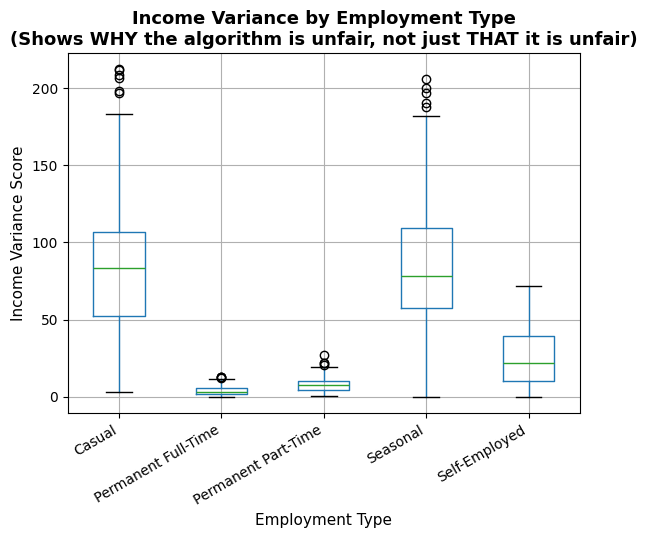

Chart 3 saved.


In [59]:
plt.figure(figsize=(10, 6))

df.boxplot(column='income_variance_score',
           by='employment_type',
           grid=True)

plt.title("Income Variance by Employment Type\n(Shows WHY the algorithm is unfair, not just THAT it is unfair)",
          fontsize=13, fontweight='bold')
plt.suptitle('')

plt.xlabel("Employment Type", fontsize=11)
plt.ylabel("Income Variance Score", fontsize=11)

plt.xticks(rotation=30, ha='right')

plt.savefig('chart3_variance_boxplot.png', dpi=150, bbox_inches='tight')

plt.xticks(rotation=30, ha='right')

plt.show()

print("Chart 3 saved.")

## SECTION 4: Bias Metric Calculation

- A Disparate Impact Ratio (DIR) is a simple bias metric.
- DIR = (debt flag rate of affected group) / (debt flag rate of least affected group)
- A DIR > 2.0 suggests significant disparate impact.

##### 4.1 - Calculate the DIR for employment type

1. Find the HIGHEST debt flag rate in emp_group['debt_flag_rate_%']
2. Find the LOWEST non-zero debt flag rate in emp_group['debt_flag_rate_%']
3. DIR = highest / lowest
4. Print the result with a descriptive message

In [60]:
rates = emp_group['debt_flag_rate_%']
highest_rate = rates.max()
non_zero_rates = rates[rates > 0]
lowest_non_zero = non_zero_rates.min()

DIR = highest_rate / lowest_non_zero
print(f'The DIR for employment type is {DIR:.2f} to 2 significant figures')


The DIR for employment type is 9.98 to 2 significant figures


##### 4.2 - Calculate the DIR for region using region_group

In [61]:
rates = region_group['debt_flag_rate_%']
highest_rate = rates.max()
non_zero_rates = rates[rates > 0]
lowest_non_zero = non_zero_rates.min()

DIR = highest_rate / lowest_non_zero
print(f'The DIR for region is {DIR:.2f} to 2 significant figures')

The DIR for region is 2.81 to 2 significant figures


## SECTION 5: Feature Importance (Decision Tree)
- A decision tree can tell us which features (columns) the algorithm relies on most heavily to predict a debt flag.
- This helps identify WHICH attributes drive the bias.

##### Data preparation (provided)

In [62]:
features = ['employment_type', 'region', 'age_bracket', 'payment_type',
            'income_variance_score']

df_model = df[features + ['debt_raised_flag']].copy()

le = LabelEncoder()
for col in ['employment_type', 'region', 'age_bracket', 'payment_type']:
    df_model[col] = le.fit_transform(df_model[col])

X = df_model[features]
y = df_model['debt_raised_flag']

##### 5.1 - Create and train a DecisionTreeClassifier
- Use max_depth=4 and random_state=42
- Fit the model on X and y

In [63]:
clf = DecisionTreeClassifier(max_depth=4, random_state=42)
clf.fit(X, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

##### 5.2 - Create a horizontal bar chart of feature importances
- Hint: use clf.feature_importances_ for the values and features for labels
- Sort from highest to lowest importance
- Title: 'Feature Importances: What Drives the Debt Flag?'
- Save as 'chart4_feature_importance.png'

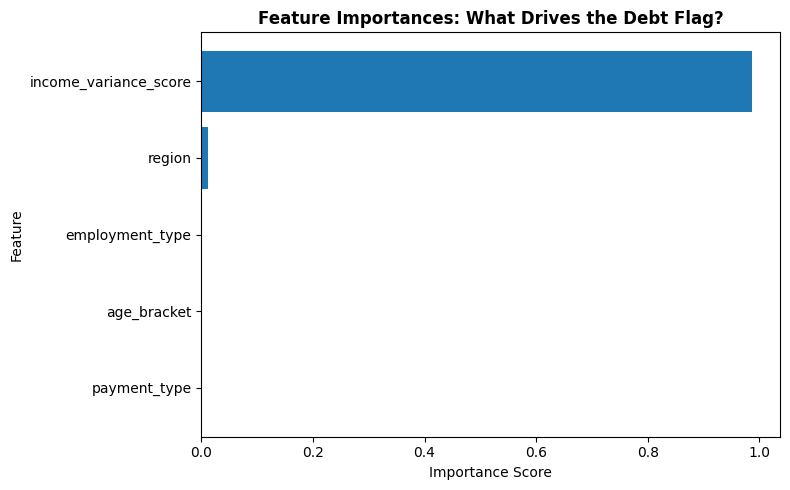

In [64]:
importances = clf.feature_importances_

feat_df = pd.DataFrame({
    'feature': features,
    'importance': importances
})

feat_df = feat_df.sort_values(by='importance', ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(feat_df['feature'], feat_df['importance'])
plt.gca().invert_yaxis()  

plt.title('Feature Importances: What Drives the Debt Flag?', fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')

plt.tight_layout()
plt.savefig('chart4_feature_importance.png', dpi=150)
plt.show()

## SECTION 6: Written Summary


### QUESTION 1: What type of bias is present in this dataset, and which groups are most affected?

The provided dataset demonstrates a form of measurement bias known as systematic averaging bias. This occurs because the algorithm inaccurately represents actual income by assuming a person’s earnings are evenly distributed over a given year. As a result, employment types with non-linear income patterns are the most affected. In accordance with the machine learning bias audit, this includes seasonal, casual, and self-employed workers, who subsequently have high income variability.
​
### QUESTION 2: Explain WHY the averaging algorithm produces unfair outcomes for certain employment types.
​
The averaging algorithm produces unfair outcomes due to the fact that it incorrectly assumes income for all employment types is evenly distributed throughout the financial year. While this may be the case for some employment types, it does not account for all. The box plot of Income Variance by Employment Type clearly shows that casual and seasonal workers have a much wider spread, thus indicating a highly variable income when compared to other employment types, such as permanent part-time and full-time workers. When the averaging algorithm divides an individual's income by 26, it subsequently fails to account for these fluctuations. Rather, the algorithm assigns income to periods where it was not actually earned, thus leading to systematic overestimation during low-income fortnights. The bar chart for Automated Debt Flag Rate by Employment Type provides evidence for this pattern as it shows significantly higher debt flag rates for the same employment types raised earlier (seasonal, casual and self-employed). In addition, the calculated Disparate Impact Ratio (DIR) of 9.98 reveals that the most affected employment group is almost 10 times as likely to be flagged as the least. This extreme disparity between employment types provides clear evidence of systematic averaging bias as workers with irregular income are disproportionately impacted. Both the flag rates and variance spread, combined with the bias metric, highlight the underlying error in the averaging algorithm, showing how averaging directly causes unfair outcomes by misrepresenting how income is earned across all employment types.
​
### QUESTION 3: Connect your findings to the real Robodebt case. 
​
The findings from the machine learning bias audits closely mirror the real Robodebt scheme (2016–2019), which relied on the same averaging algorithm to calculate debts. In both cases, the algorithm failed to accurately account for employment groups with irregular income patterns, resulting in a disproportionate number of debt flags raised for seasonal, casual and self-employed workers. The 2023 Royal Commission into the Robodebt Scheme deemed this method of calculation to be fundamentally flawed as a result of the same structural issues. Specifically, it concluded that averaging annual income in order to determine fortnightly earnings for individuals was unlawful and unreliable. The audit conducted on the modelled data demonstrates how the flawed logic causes systematic false positives, leading to individuals being flagged incorrectly due to inconsistencies in the averaging algorithm. In summation, both the real-world Robodebt system and the modelled dataset underscore the present risk in relying on simplified assumptions in automated decision-making, showcasing how such oversights can lead to significant financial harm to disadvantaged groups.
​
### QUESTION 4: Propose ONE concrete technical mitigation strategy that could reduce this bias. 
​
A concrete mitigation strategy to reduce the systematic averaging bias found in the dataset is to introduce actual fortnight-by-fortnight income matching. Rather than comparing a user's reported income to an average spread among an entire year, the proposed system would utilise verified income for each specific fortnight to be directly compared against what was reported in that same period. To attain this verified income, the system will integrate data sources with greater detail, such as records directly from employers that detail the exact income at the specific time it was paid. Through the removal of the assumption that income is evenly distributed among all employment groups, the mitigation directly targets the main cause of the measurement bias. This strategy will improve fairness for employment groups with high income variance. The bias audit demonstrates that these employment groups are seasonal, casual and self-employed workers. As a result of utilising real income fluctuations rather than a smoothed out average, the extreme disparity of 9.98 found in the DIR for debt flag rates among employment types would seemingly disappear, as each individual, regardless of variance, would be assessed based on their actual earnings. Thus, the number of false positives for debt flags would be reduced significantly. However, this strategy does introduce trade-offs. As the system requires an increase in data collection to attain an individual's real income every fortnight, an increase in computational complexity may arise. This increase will most likely raise implementation costs and create potential gaps where data is unavailable. Overall, despite these limitations, this potential mitigation strategy significantly reduces the systematic averaging bias found in the dataset. This results in a more accurate, fair, and reliable system that better reflects real-world income patterns.
